In [159]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor

INPUT = "/neurospin/signatures/2026_ychaoub_rlink_predict_response_clinic/data/"


Clinical_df = pd.read_excel(INPUT + 'statistic_data.xlsx')


In [173]:
Clinical_df


,participant_id,CENTERNUM,Male sex,AGE,Current mood episode (MOODYN_PRELI),Type of episode (TYPEP_PRELI),With mixed characteristics (MIX_PRELI),Currently hospitalized (HOSP_PRELI),Weight (WEIGHT_PRELI),Height (HEIGHT_PRELI),...,DurationIllness,SuicideAttempts(Yes/No),DensityHospit,Psychiatric_Comorbidity,AgeAtOnset,NumberPreviousEpisodes,DensityEpisodes,BMI_M00,Lithium Response (4 levels),response_label
0,sub-10289,16,1,59,1,3,0,0,88.50,175,...,21,0,0.095238,0,38,5,0.238095,28.897959,1,No_GR
1,sub-11327,2,2,18,1,2,0,1,50.00,165,...,3,0,0.666667,1,15,4,1.333333,18.365473,1,No_GR
2,sub-11841,7,1,41,1,2,0,1,70.00,170,...,7,0,0.285714,0,34,3,0.428571,24.221453,0,GR
3,sub-14116,12,1,28,0,1,0,0,85.00,178,...,13,0,0.000000,0,21,9,1.000000,26.827421,1,No_GR
4,sub-14393,15,2,64,1,1,0,0,55.00,164,...,7,0,0.000000,0,57,4,0.571429,20.449137,1,No_GR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,sub-96244,4,1,33,1,1,0,0,75.25,171,...,21,0,0.000000,1,12,120,5.714286,24.221453,1,No_GR
134,sub-96357,4,2,28,1,2,0,0,52.00,172,...,13,0,0.076923,1,15,21,1.615385,17.577069,1,No_GR
135,sub-96826,15,2,40,1,1,0,1,68.00,159,...,6,1,0.333333,0,34,10,1.666667,26.897670,1,No_GR
136,sub-98872,7,1,45,1,1,0,0,83.20,175,...,12,0,0.166667,0,33,1,0.083333,27.167347,0,GR


In [161]:

### X, y ###

y = Clinical_df["Lithium Response (4 levels)"]

X = Clinical_df.drop(columns=["Lithium Response (4 levels)", "participant_id"])




# Convertir toutes les colonnes object en float
X[X.select_dtypes(include='object').columns] = (
    X.select_dtypes(include='object').astype(float)
)

# Vérification
print(X.dtypes.value_counts())




int64      133
float64     17
Name: count, dtype: int64


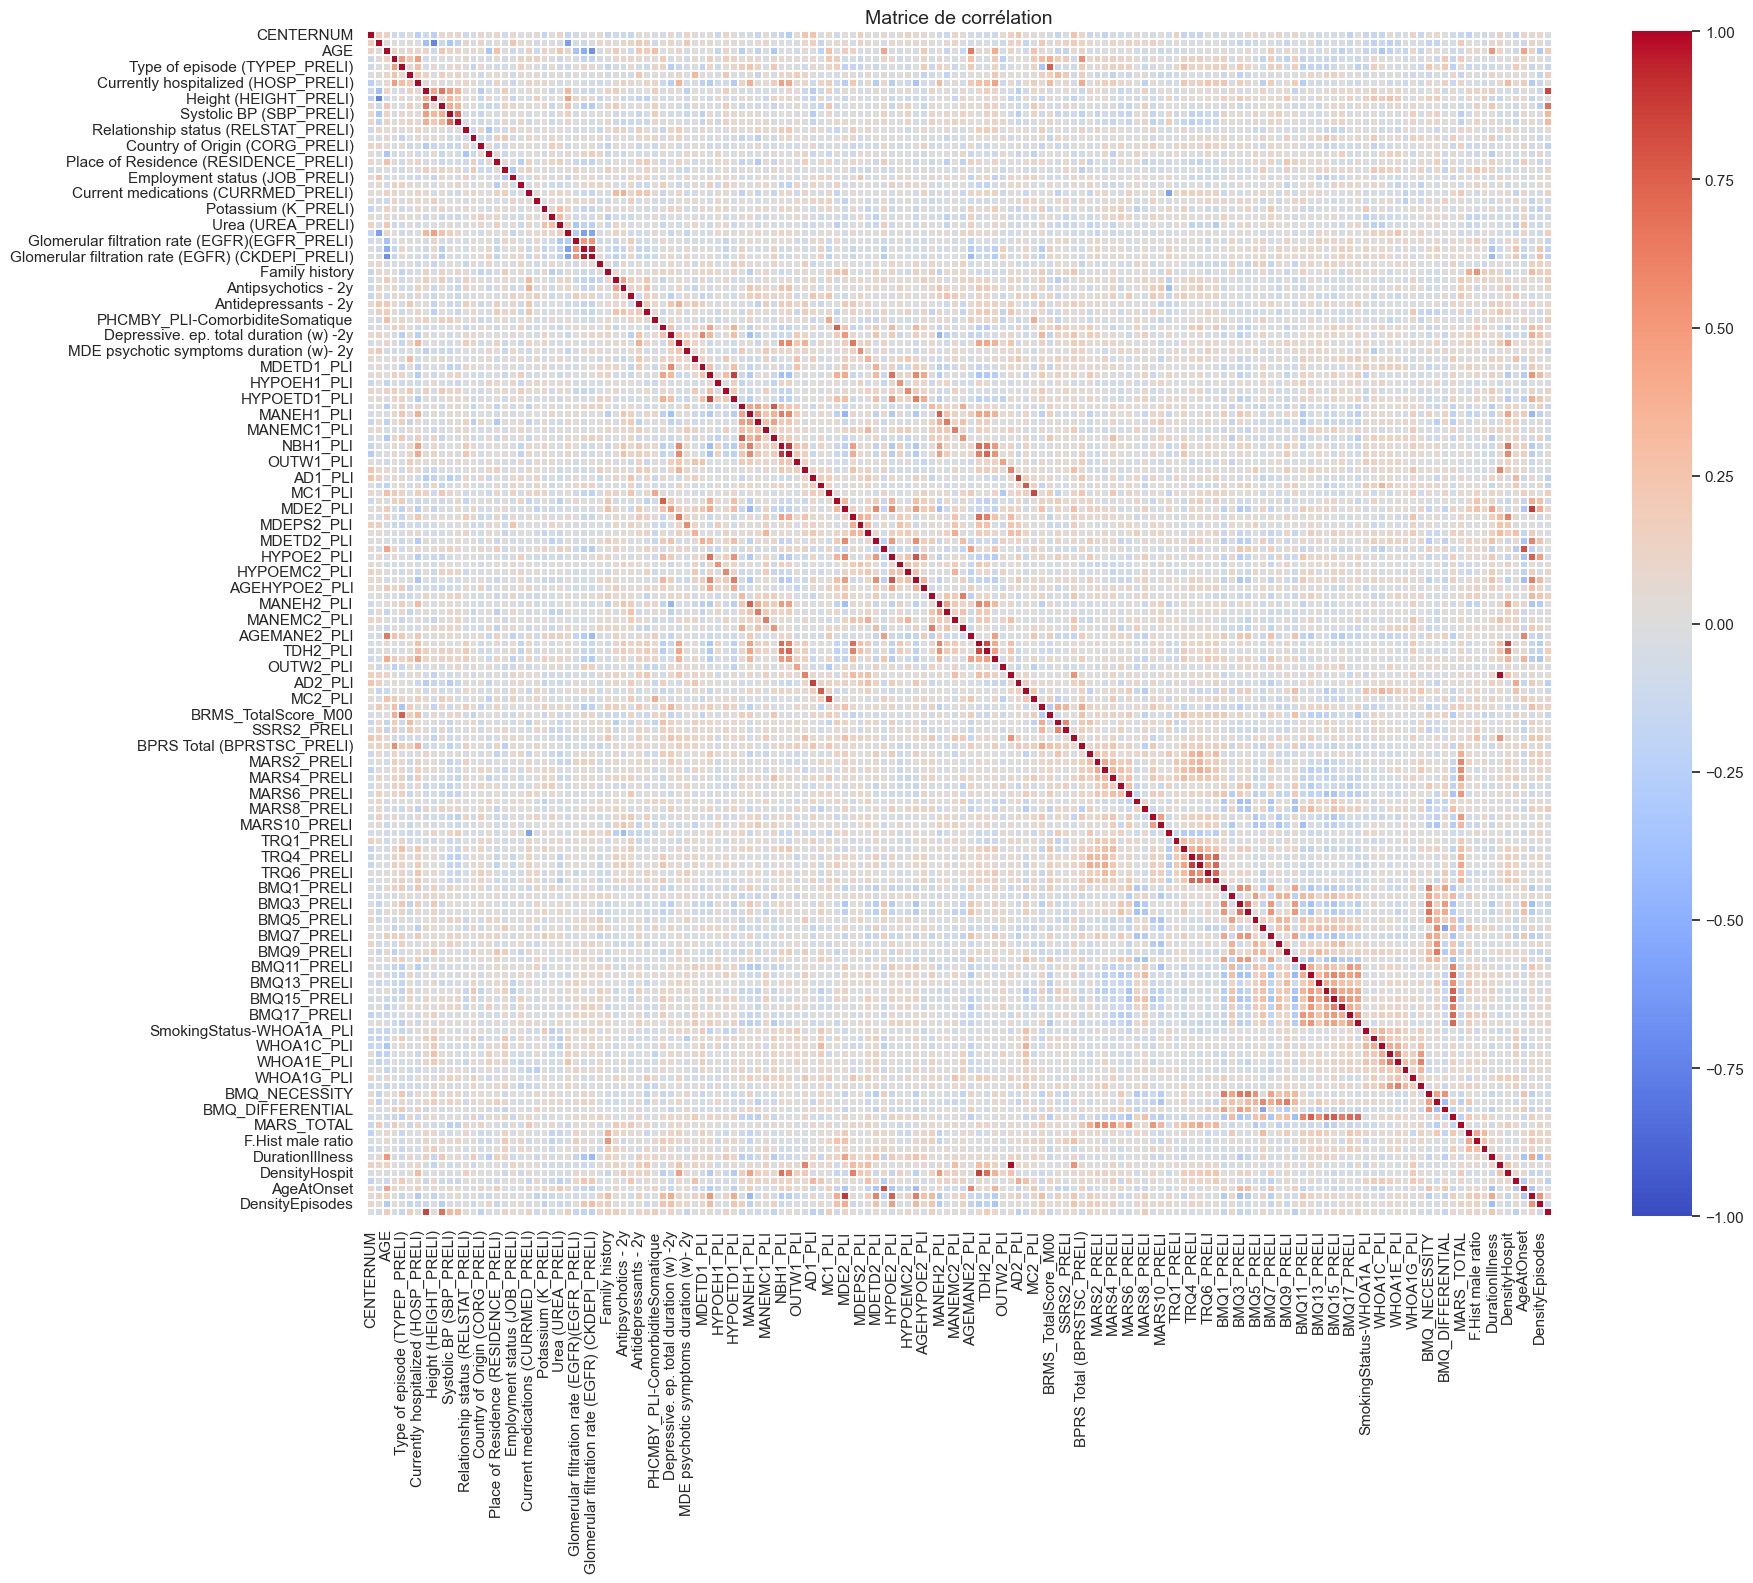

In [ ]:
### Correlation matrix

corr_matrix = X.corr(method="spearman")

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    annot=False,        
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    square=True,
)
plt.title("Matrice de corrélation", fontsize=14)
plt.tight_layout()
# plt.savefig('Matrice de correlation')
plt.show()





In [163]:


# Seuil de corrélation
threshold = 0.85

# Extraction des fortes corrélations
strong_corr = (
    corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

# Renommer les colonnes
strong_corr.columns = ['Variable_1', 'Variable_2', 'Correlation']

# Filtrer selon le seuil
strong_corr = strong_corr[
    strong_corr['Correlation'].abs() > threshold
]

# Trier par corrélation absolue décroissante
strong_corr = strong_corr.reindex(
    strong_corr['Correlation'].abs().sort_values(ascending=False).index
)

# Affichage
print(strong_corr)
strong_corr

# The most correlated variables with each other
# Variable_1                                              Variable_2                                         Correlation
# NBS2_PLI                                               SuicideAttempts(Yes/No)                             0.991790
# Glomerular filtration rate (EGFR) MDRD (MDRD_PRELI)   Glomerular filtration rate (EGFR) (CKDEPI_PRELI)     0.952948
# NBH1_PLI                                               TDH1_PLI                                            0.894335
# MDE2_PLI                                               NumberPreviousEpisodes                              0.885562
# TRQ4_PRELI                                             TRQ5_PRELI                                          0.871946
# AD1_PLI                                                AD2_PLI                                             0.870392
# NbHospitalizationsLifetime                             DensityHospit                                       0.862817
# HYPOE1_PLI                                             HYPOETD1_PLI                                        0.859697
# Weight (WEIGHT_PRELI)                                  BMI_M00                                             0.851385


                                              Variable_1  \
8890                                            NBS2_PLI   
3672   Glomerular filtration rate (EGFR) MDRD (MDRD_P...   
6422                                            NBH1_PLI   
7256                                            MDE2_PLI   
10140                                         TRQ4_PRELI   
6829                                             AD1_PLI   
8613                          NbHospitalizationsLifetime   
5506                                          HYPOE1_PLI   
1163                               Weight (WEIGHT_PRELI)   

                                             Variable_2  Correlation  
8890                            SuicideAttempts(Yes/No)     0.991790  
3672   Glomerular filtration rate (EGFR) (CKDEPI_PRELI)     0.952948  
6422                                           TDH1_PLI     0.894335  
7256                             NumberPreviousEpisodes     0.885562  
10140                                       

,Variable_1,Variable_2,Correlation
8890,NBS2_PLI,SuicideAttempts(Yes/No),0.991790
3672,Glomerular filtration rate (EGFR) MDRD (MDRD_P...,Glomerular filtration rate (EGFR) (CKDEPI_PRELI),0.952948
6422,NBH1_PLI,TDH1_PLI,0.894335
7256,MDE2_PLI,NumberPreviousEpisodes,0.885562
10140,TRQ4_PRELI,TRQ5_PRELI,0.871946
6829,AD1_PLI,AD2_PLI,0.870392
8613,NbHospitalizationsLifetime,DensityHospit,0.862817
5506,HYPOE1_PLI,HYPOETD1_PLI,0.859697
1163,Weight (WEIGHT_PRELI),BMI_M00,0.851385


BMQ  : ['BMQ1_PRELI', 'BMQ2_PRELI', 'BMQ3_PRELI', 'BMQ4_PRELI', 'BMQ5_PRELI', 'BMQ6_PRELI', 'BMQ7_PRELI', 'BMQ8_PRELI', 'BMQ9_PRELI', 'BMQ10_PRELI', 'BMQ11_PRELI', 'BMQ12_PRELI', 'BMQ13_PRELI', 'BMQ14_PRELI', 'BMQ15_PRELI', 'BMQ16_PRELI', 'BMQ17_PRELI', 'BMQ18_PRELI', 'BMQ_NECESSITY', 'BMQ_PREOCCUPATION', 'BMQ_DIFFERENTIAL', 'BMQ_GENERAL']
MARS : ['MARS1_PRELI', 'MARS2_PRELI', 'MARS3_PRELI', 'MARS4_PRELI', 'MARS5_PRELI', 'MARS6_PRELI', 'MARS7_PRELI', 'MARS8_PRELI', 'MARS9_PRELI', 'MARS10_PRELI', 'MARS_TOTAL']
TRQ  : ['TRQ_PRELI', 'TRQ1_PRELI', 'TRQ2_PRELI', 'TRQ4_PRELI', 'TRQ5_PRELI', 'TRQ6_PRELI', 'TRQ7_PRELI']


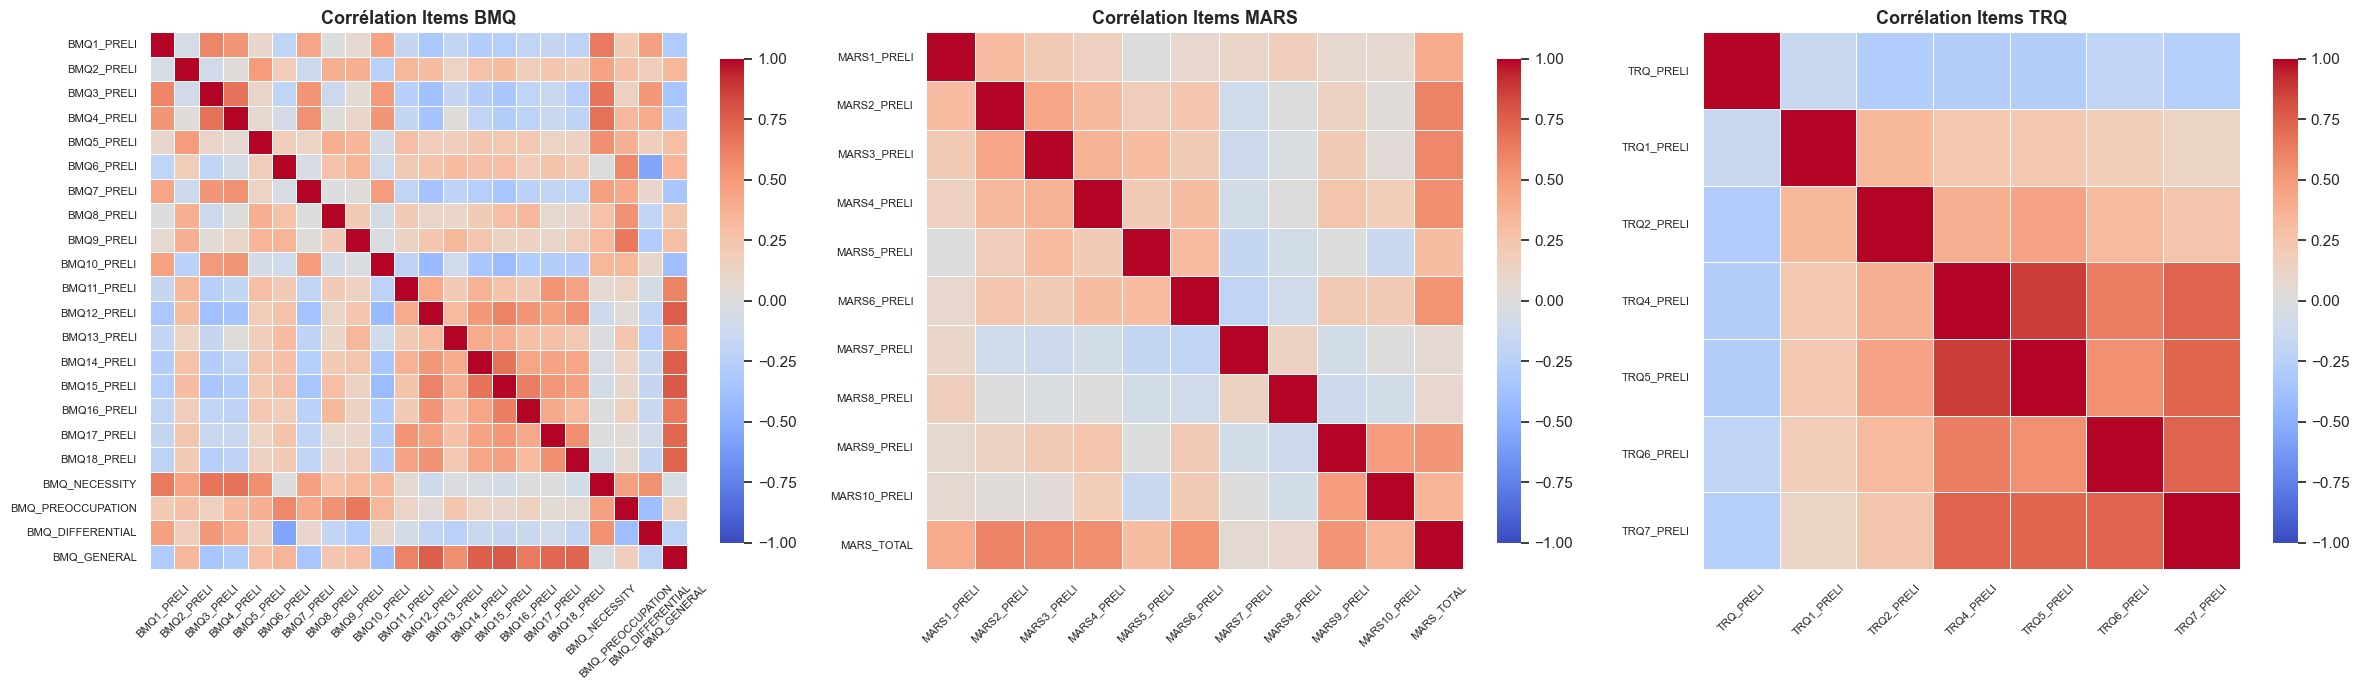

In [164]:

## Correlation of BMQ, MARS and TRQ
#  Sélection des variables 
bmq_cols  = [c for c in X.columns if 'BMQ'  in str(c)]
mars_cols = [c for c in X.columns if 'MARS' in str(c)]
trq_cols  = [c for c in X.columns if 'TRQ'  in str(c)]

print("BMQ  :", bmq_cols)
print("MARS :", mars_cols)
print("TRQ  :", trq_cols)

#  Matrices de corrélation 
corr_bmq  = X[bmq_cols].corr(method="spearman")
corr_mars = X[mars_cols].corr(method="spearman")
corr_trq  = X[trq_cols].corr(method="spearman")

#  Visualisation 
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# --- BMQ ---
sns.heatmap(corr_bmq,
            ax=axes[0],
            annot=False,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            vmin=-1,
            vmax=1,
            linewidths=0.4,
            square=True,
            cbar_kws={"shrink": 0.8})

axes[0].set_title("Corrélation Items BMQ",
                  fontsize=13,
                  fontweight="bold")
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].tick_params(axis="y", rotation=0, labelsize=8)

# --- MARS ---
sns.heatmap(corr_mars,
            ax=axes[1],
            annot=False,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            vmin=-1,
            vmax=1,
            linewidths=0.4,
            square=True,
            cbar_kws={"shrink": 0.8})

axes[1].set_title("Corrélation Items MARS",
                  fontsize=13,
                  fontweight="bold")
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].tick_params(axis="y", rotation=0, labelsize=8)

# --- TRQ ---
sns.heatmap(corr_trq,
            ax=axes[2],
            annot=False,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            vmin=-1,
            vmax=1,
            linewidths=0.4,
            square=True,
            cbar_kws={"shrink": 0.8})

axes[2].set_title("Corrélation Items TRQ",
                  fontsize=13,
                  fontweight="bold")
axes[2].tick_params(axis="x", rotation=45, labelsize=8)
axes[2].tick_params(axis="y", rotation=0, labelsize=8)

plt.tight_layout()

# plt.savefig("corr_bmq_mars_trq.png",dpi=150,bbox_inches="tight")

plt.show()




In [165]:


### Multicolinerarity assessment: Matrix and VIF 

# ── Calcul du VIF ─────────────────────────────────────────────────────────────
def compute_vif(X):
    vif = pd.DataFrame()
    vif["feature"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif.sort_values("VIF", ascending=False).reset_index(drop=True)

vif_df = compute_vif(X)
print(vif_df)


# The VIF results contain infinite values, which confirms the presence of multicollinearity,
# therefore we will apply regularization methods to handle it in the models

/home/yc287630/.local/lib/python3.8/site-packages/statsmodels/stats/outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


         feature  VIF
0      CENTERNUM  inf
1    MARS4_PRELI  inf
2    MARS6_PRELI  inf
3    MARS7_PRELI  inf
4    MARS8_PRELI  inf
..           ...  ...
145  MANEMC1_PLI  inf
146  MANETD1_PLI  inf
147     NBH1_PLI  inf
148     TDH1_PLI  inf
149      BMI_M00  inf

[150 rows x 2 columns]


In [166]:
#Descriptive Statistics
Clinical_df.describe().round(2)

,CENTERNUM,Male sex,AGE,Current mood episode (MOODYN_PRELI),Type of episode (TYPEP_PRELI),With mixed characteristics (MIX_PRELI),Currently hospitalized (HOSP_PRELI),Weight (WEIGHT_PRELI),Height (HEIGHT_PRELI),WAIST_PRELI,...,F.Hist positive lithium response,DurationIllness,SuicideAttempts(Yes/No),DensityHospit,Psychiatric_Comorbidity,AgeAtOnset,NumberPreviousEpisodes,DensityEpisodes,BMI_M00,Lithium Response (4 levels)
count,138.00,138.00,138.00,138.00,138.00,138.00,138.00,138.00,138.00,138.00,...,138.00,138.00,138.00,138.00,138.00,138.00,138.00,138.00,138.00,138.00
mean,8.76,1.51,40.31,0.64,1.41,0.11,0.30,77.81,171.57,91.18,...,0.03,15.66,0.23,0.18,0.36,24.71,16.00,1.42,26.03,0.64
std,4.60,0.50,12.98,0.48,0.68,0.31,0.46,18.22,9.57,15.08,...,0.14,11.48,0.42,0.32,0.48,11.42,19.43,1.76,5.17,0.48
min,1.00,1.00,18.00,0.00,1.00,0.00,0.00,49.00,150.00,31.00,...,0.00,0.00,0.00,0.00,0.00,7.00,1.00,0.08,17.58,0.00
25%,5.00,1.00,28.00,0.00,1.00,0.00,0.00,64.00,165.00,84.10,...,0.00,7.00,0.00,0.00,0.00,17.00,4.00,0.50,22.51,0.00
50%,9.00,2.00,40.00,1.00,1.00,0.00,0.00,75.25,171.00,90.00,...,0.00,13.00,0.00,0.07,0.00,21.00,9.00,1.00,24.69,1.00
75%,12.00,2.00,52.00,1.00,2.00,0.00,1.00,87.42,177.75,99.75,...,0.00,22.00,0.00,0.20,1.00,29.00,19.50,1.65,28.73,1.00
max,16.00,2.00,69.00,1.00,3.00,1.00,1.00,163.00,194.00,135.00,...,1.00,45.00,1.00,2.00,1.00,65.00,120.00,11.67,48.00,1.00


In [167]:
sns.set_theme(style="whitegrid")

Text(0.5, 1.0, 'Age Distribution')

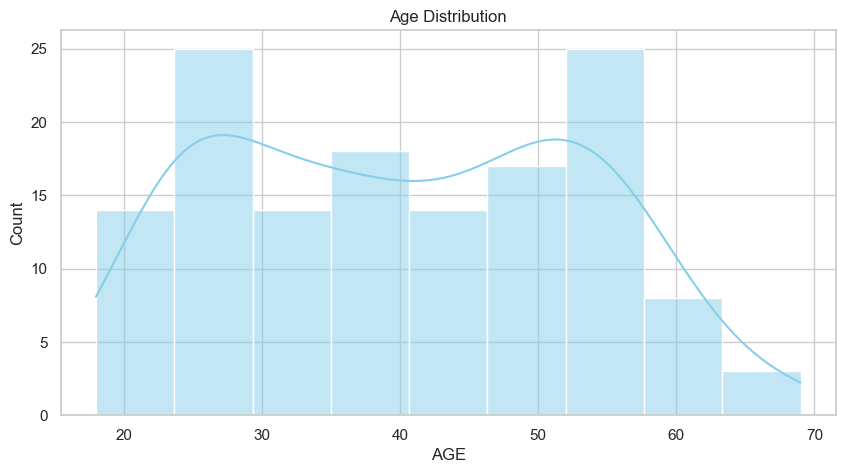

In [168]:
#Distribution of Age
plt.figure(figsize=(10,5))


sns.histplot(Clinical_df["AGE"],kde=True,color='skyblue')
plt.title('Age Distribution')


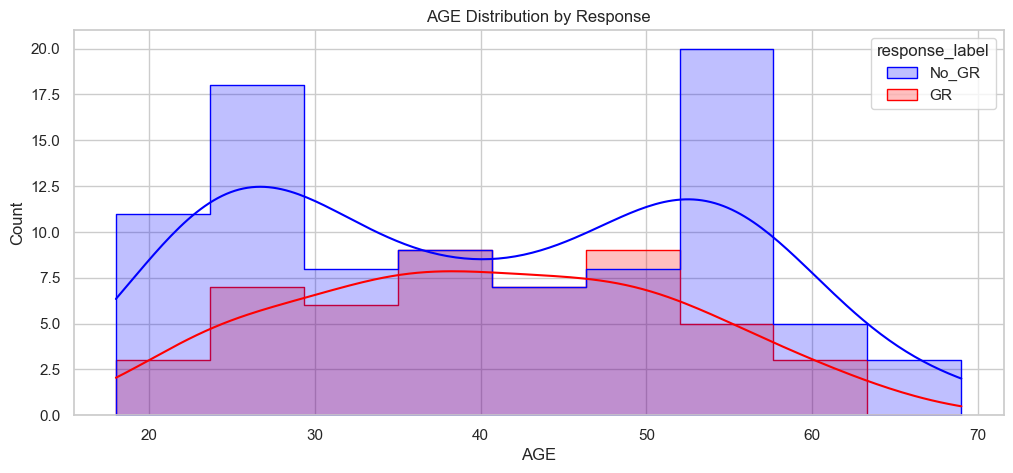

In [169]:
Clinical_df['response_label'] = Clinical_df['Lithium Response (4 levels)'].map({
    0: 'GR',
    1: 'No_GR'
})

plt.figure(figsize=(12,5))
sns.histplot(
    data=Clinical_df,
    x="AGE",
    hue="response_label",
    kde=True,
    element="step",
    palette={"GR":"red", "No_GR":"blue"}
)

plt.title("AGE Distribution by Response")
plt.savefig('Distribution de AGE en fct de Response')

plt.show()

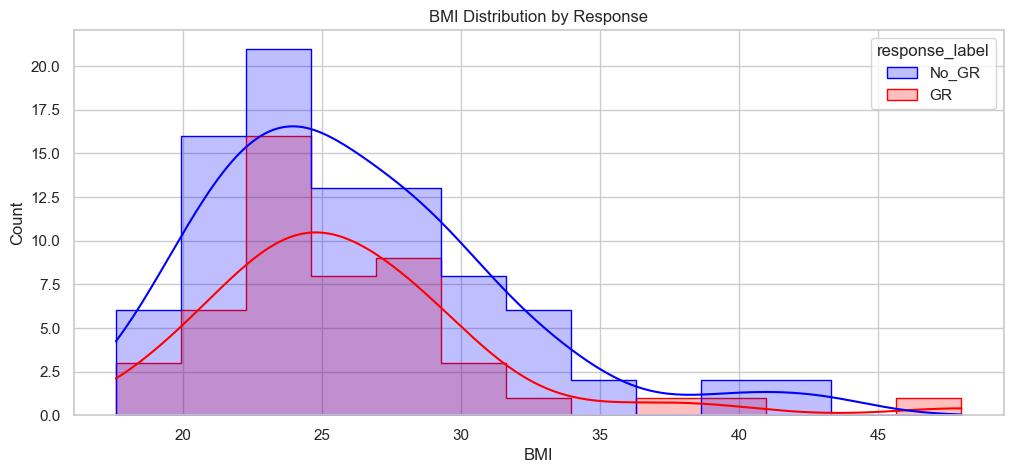

In [170]:
# Response mapping
Clinical_df['response_label'] = Clinical_df['Lithium Response (4 levels)'].map({
    0: 'GR',
    1: 'No_GR'
})

# BMI Distribution
plt.figure(figsize=(12,5))

sns.histplot(
    data=Clinical_df,
    x="BMI_M00",
    hue="response_label",
    kde=True,
    element="step",
    palette={"GR": "red", "No_GR": "blue"}
)

plt.title('BMI Distribution by Response')
plt.xlabel('BMI')
plt.ylabel('Count')

plt.savefig('BMI_Distribution_by_Response.png', dpi=300, bbox_inches='tight')

plt.show()

/tmp/ipykernel_2066541/2023634309.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


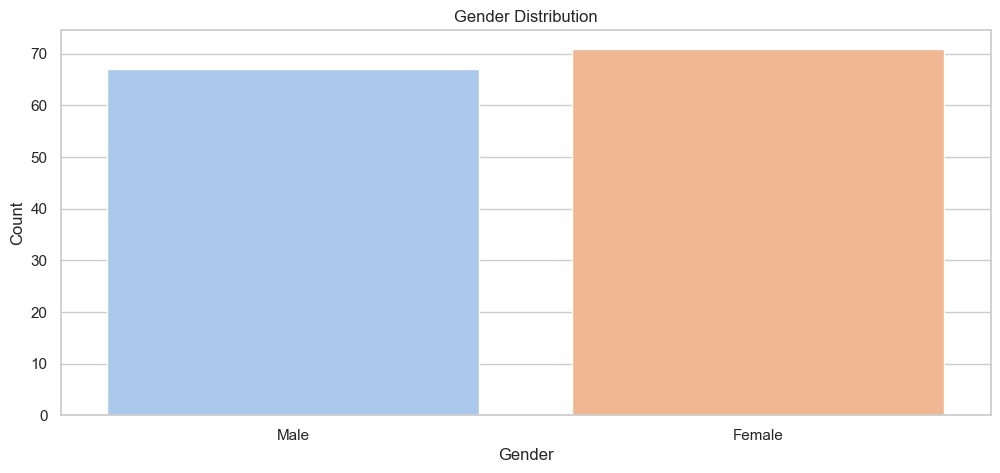

In [175]:
# Map SEX values to labels
Clinical_df['SEX_label'] = Clinical_df['Male sex'].map({
    1: 'Male',
    2: 'Female',
    3: 'Other'
})

# Gender distribution plot
plt.figure(figsize=(12,5))

sns.countplot(
    x="SEX_label",
    data=Clinical_df,
    palette='pastel'
)

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.savefig('Gender_Distribution.png', dpi=300, bbox_inches='tight')

plt.show()

/tmp/ipykernel_2066541/3415178551.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Lithium Response (4 levels)",data=Clinical_df,palette='pastel')


Text(0.5, 1.0, 'output Distribution')

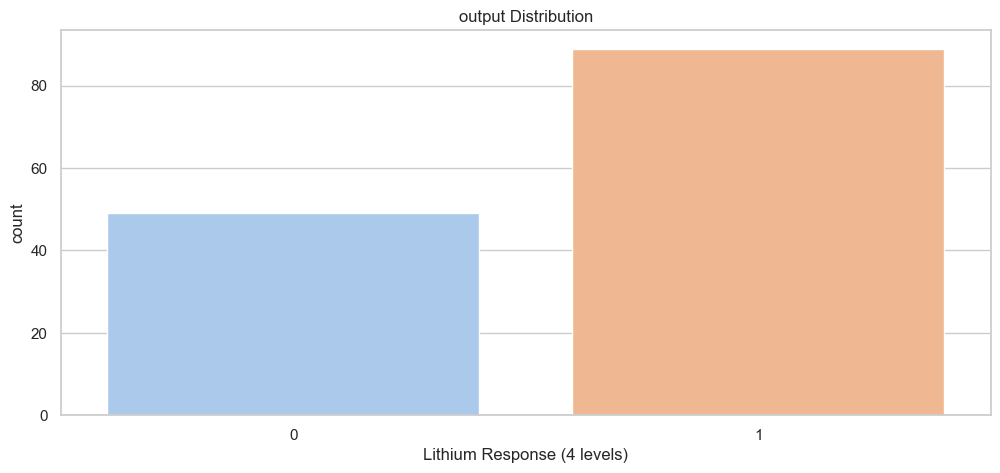

In [177]:
#Variable OUTPUT

plt.figure(figsize=(12,5))
sns.countplot(x="Lithium Response (4 levels)",data=Clinical_df,palette='pastel')
plt.title('output Distribution')

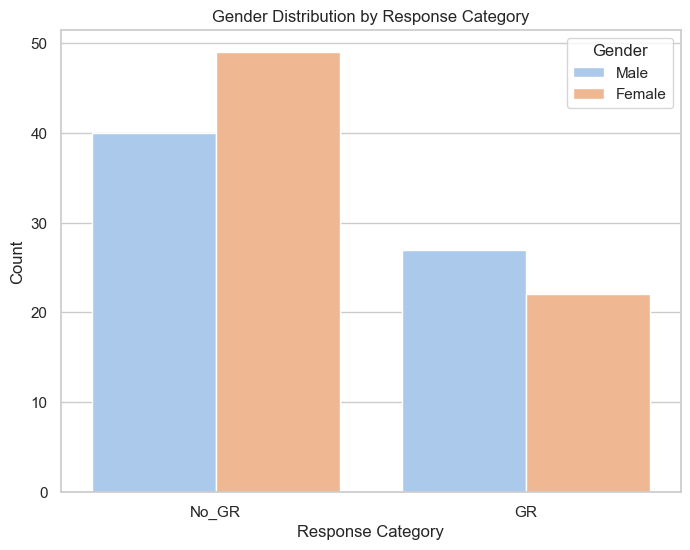

In [178]:
# Mapping variables
Clinical_df['response_label'] = Clinical_df['Lithium Response (4 levels)'].map({
    0: 'GR',
    1: 'No_GR'
})

Clinical_df['SEX_label'] = Clinical_df['Male sex'].map({
    1: 'Male',
    2: 'Female',
    3: 'Other'
})

# Plot
plt.figure(figsize=(8,6))

sns.countplot(
    x="response_label",
    hue="SEX_label",
    data=Clinical_df,
    palette='pastel'
)

plt.title('Gender Distribution by Response Category')
plt.xlabel('Response Category')
plt.ylabel('Count')

plt.legend(title='Gender')

plt.savefig('Gender_by_Response.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

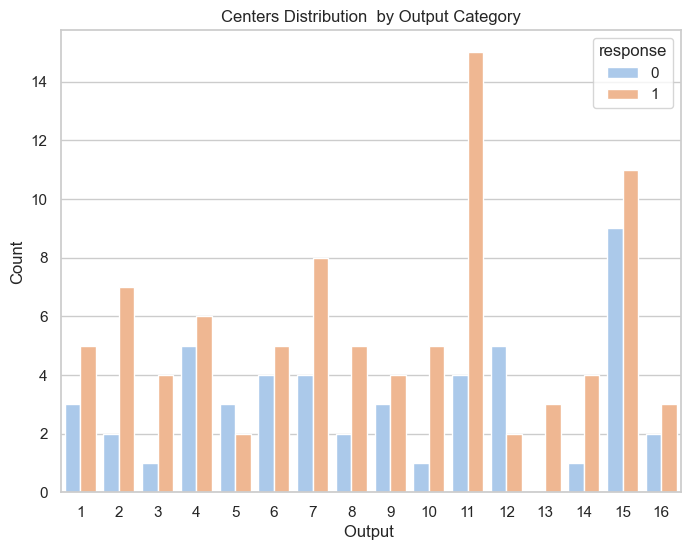

In [179]:
plt.figure(figsize=(8,6))
sns.countplot(x="CENTERNUM",hue="Lithium Response (4 levels)",data=Clinical_df,palette='pastel')
plt.title('Centers Distribution  by Output Category')
plt.xlabel('Output ')
plt.ylabel('Count')
plt.legend(title='response')
plt.show

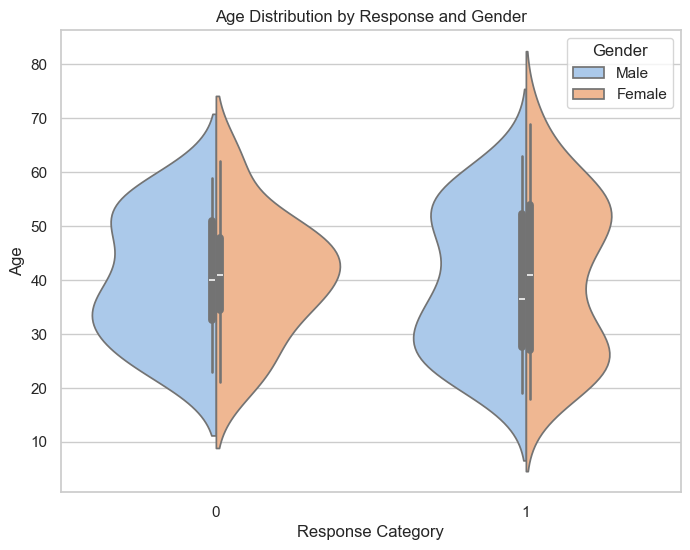

In [180]:
# variable numérique : AGE

plt.figure(figsize=(8,6))

sns.violinplot(
    x="Lithium Response (4 levels)",
    y="AGE",
    hue="SEX_label",
    data=Clinical_df,
    palette="pastel",
    split=True
)

plt.title('Age Distribution by Response and Gender')
plt.xlabel('Response Category')
plt.ylabel('Age')

plt.legend(title='Gender')

plt.savefig('Violin_Age_by_Response.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

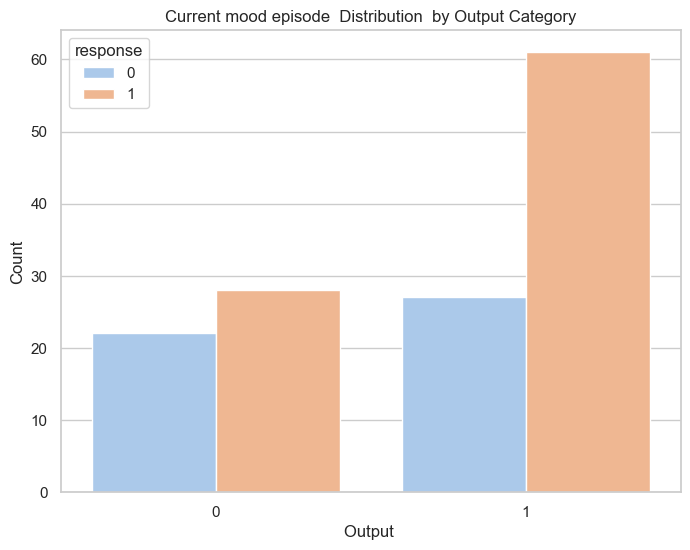

In [182]:
plt.figure(figsize=(8,6))
sns.countplot(x="Current mood episode (MOODYN_PRELI)",hue="Lithium Response (4 levels)",data=Clinical_df,palette='pastel')
plt.title('Current mood episode  Distribution  by Output Category')
plt.xlabel('Output ')
plt.ylabel('Count')
plt.legend(title='response')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

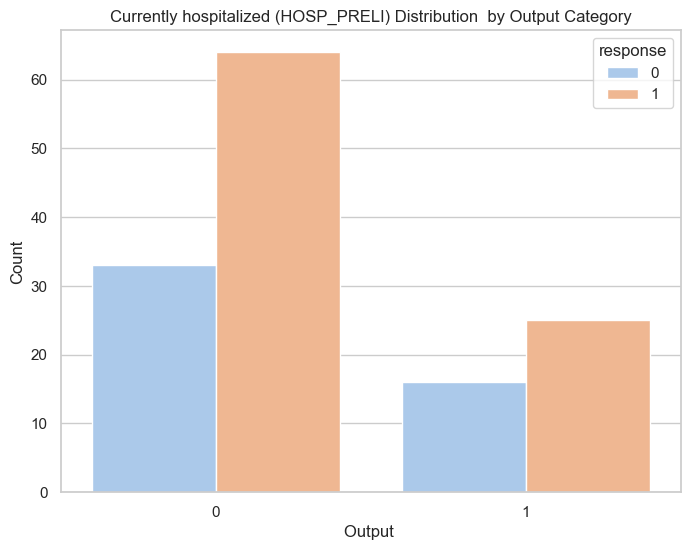

In [184]:
plt.figure(figsize=(8,6))
sns.countplot(x="Currently hospitalized (HOSP_PRELI)",hue="Lithium Response (4 levels)",data=Clinical_df,palette='pastel')
plt.title('Currently hospitalized (HOSP_PRELI) Distribution  by Output Category')
plt.xlabel('Output ')
plt.ylabel('Count')
plt.legend(title='response')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

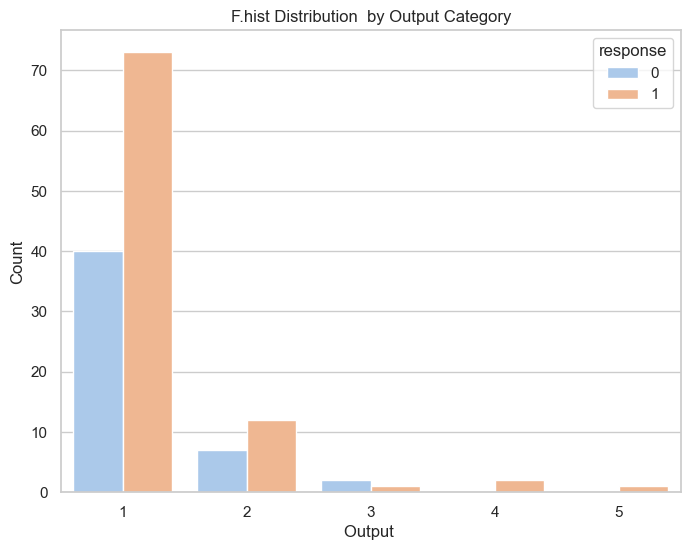

In [185]:
plt.figure(figsize=(8,6))
sns.countplot(x="F.hist absolute count",hue="Lithium Response (4 levels)",data=Clinical_df,palette='pastel')
plt.title('F.hist Distribution  by Output Category')
plt.xlabel('Output ')
plt.ylabel('Count')
plt.legend(title='response')
plt.show

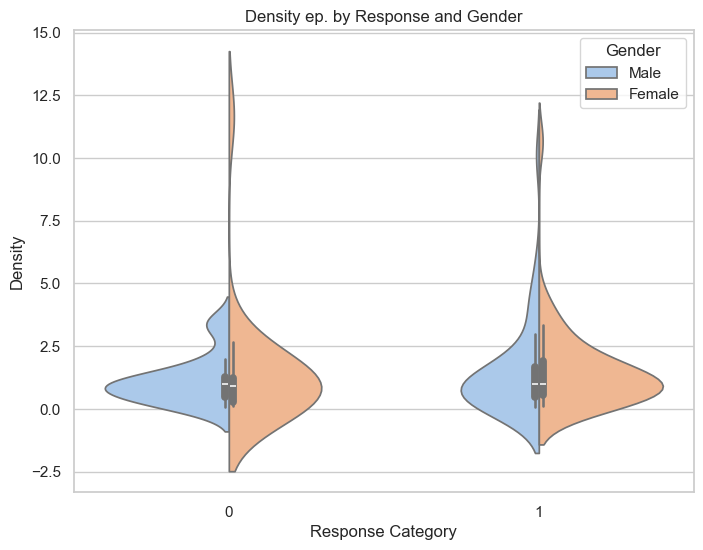

In [186]:
plt.figure(figsize=(8,6))

sns.violinplot(
    x="Lithium Response (4 levels)",
    y="DensityEpisodes",
    hue="SEX_label",
    data=Clinical_df,
    palette="pastel",
    split=True
)

plt.title('Density ep. by Response and Gender')
plt.xlabel('Response Category')
plt.ylabel('Density')

plt.legend(title='Gender')

#plt.savefig('Violin_Age_by_Response.png',dpi=300,bbox_inches='tight')

plt.show()

In [188]:
# %%
Clinical_df.loc[Clinical_df['DensityEpisodes'] < 0, 'DensityEpisodes']

Series([], Name: DensityEpisodes, dtype: float64)

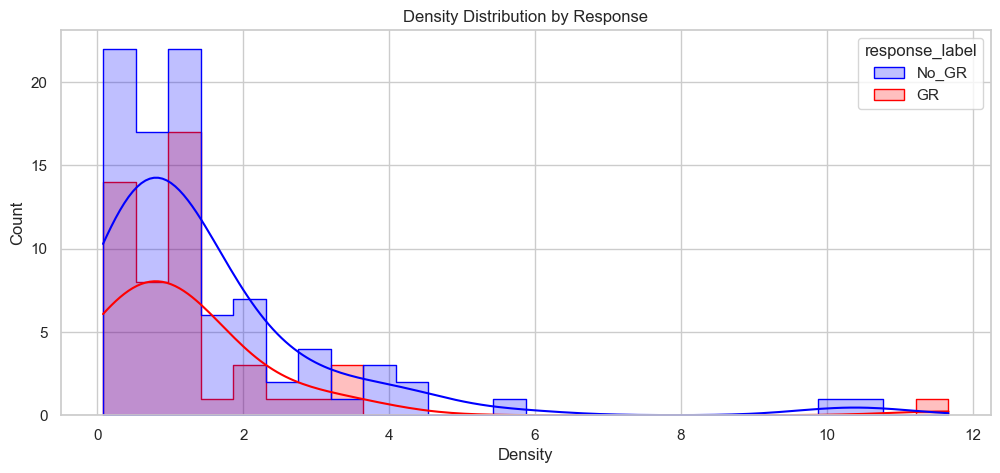

In [189]:
# Response mapping
Clinical_df['response_label'] = Clinical_df['Lithium Response (4 levels)'].map({
    0: 'GR',
    1: 'No_GR'
})

# BMI Distribution
plt.figure(figsize=(12,5))

sns.histplot(
    data=Clinical_df,
    x="DensityEpisodes",
    hue="response_label",
    kde=True,
    element="step",
    palette={"GR": "red", "No_GR": "blue"}
)

plt.title('Density Distribution by Response')
plt.xlabel('Density')
plt.ylabel('Count')

#plt.savefig('BMI_Distribution_by_Response.png', dpi=300, bbox_inches='tight')

plt.show()